# GISPR Module 2 — Spatial Foundations: Loading Data, Loops, Functions, and Version Control

**Course:** GIS Spatial Analysis with Python and R (GISPR)  
**Module:** 2 — Building a Repeatable Workflow  
**Builds on:** Module 1 (variables, data frames, functions, packages, first geometry)

---

### What you'll accomplish this module

By the end of this notebook you'll be able to:

| # | Learning outcome | Where |
|---|---|---|
| 1 | Load real spatial data, sanity-check it, trust what you're seeing | Section 1 |
| 2 | Clone the ArcGIS Pro Python environment safely | Section 2 |
| 3 | Use loops + if/else to process data automatically | Section 3 |
| 4 | Write one reusable function and call it more than once | Section 4 |
| 5 | Initialize Git, make meaningful commits, push to GitHub | Section 5 |

### Kernel reminder
- 🔵 **`[R]`** cells — switch kernel to **R** before running
- 🟢 **`[Python]`** cells — switch kernel to **Python 3** (or your cloned env) before running
- 📋 **`[Terminal]`** cells — paste the command into your terminal / Anaconda Prompt, **not** in a notebook cell

> **The goal isn't to memorize syntax.** It's to build the habit: load → inspect → process → document → save → commit.

---
## Section 1 — Load Spatial Data and Trust What You're Looking At

The first thing you do with any spatial dataset is **load it and sanity-check it** before touching anything else. This section builds that habit.

**The sanity-check checklist:**
1. Did it load without errors?
2. How many features (rows)? How many attributes (columns)?
3. What geometry type? (Point, Line, Polygon?)
4. What CRS? Is it what you expected?
5. Does the bounding box make geographic sense?
6. Are there null/missing geometries?

We'll use a freely available dataset: **US state boundaries** from the `spData` R package and `geodatasets` Python package — no files to download.

### 1a — Load spatial data in R with `sf`

In [ ]:
# [R] Load spatial data and run the full sanity-check sequence
# install.packages("spData")  # run once in your R console if needed

library(sf)
library(spData)   # comes with sample spatial datasets

# Load the built-in US states dataset
states <- us_states   # an sf object — polygons

# ── Sanity check 1: Did it load? ─────────────────────────────
cat("Class:", class(states), "\n")

# ── Sanity check 2: Dimensions ───────────────────────────────
cat("Features (rows):", nrow(states), "\n")
cat("Attributes (cols):", ncol(states), "\n")
cat("Column names:", paste(names(states), collapse = ", "), "\n")

# ── Sanity check 3: Geometry type ────────────────────────────
cat("Geometry type:", as.character(unique(st_geometry_type(states))), "\n")

# ── Sanity check 4: CRS ──────────────────────────────────────
cat("\nCRS info:\n")
print(st_crs(states))

# ── Sanity check 5: Bounding box ─────────────────────────────
cat("\nBounding box (xmin, ymin, xmax, ymax):\n")
print(st_bbox(states))

# ── Sanity check 6: Missing geometries ───────────────────────
null_geoms <- sum(st_is_empty(states))
cat("\nNull/empty geometries:", null_geoms, "\n")

# ── Preview the attribute table ───────────────────────────────
cat("\nFirst 5 rows:\n")
print(head(states[, c("NAME", "REGION", "total_pop_15")], 5))

In [ ]:
# [R] Quick plot to visually confirm the data makes sense

library(sf)
library(spData)

states <- us_states

# Plot just the geometry (no fill = outlines only)
plot(st_geometry(states),
     col  = "#d4edff",
     border = "#185FA5",
     lwd  = 0.6,
     main = "US States — sf polygon layer (EPSG:4269)")

# Plot one attribute: total population as a choropleth
plot(states["total_pop_15"],
     main   = "Total Population by State (2015)",
     border = "white",
     lwd    = 0.3)

### 1b — Load spatial data in Python with `geopandas`

In [6]:
# [Python] Load spatial data and run the full sanity-check sequence
# pip install geodatasets  # run once in terminal if needed

import geopandas as gpd
import pandas as pd
from geodatasets import get_path   # built-in sample datasets

# Load the built-in US states (naturalearth)
path = get_path("naturalearth.land")
world = gpd.read_file(path)

# Filter to contiguous area for a clean demo
# (alternatively load your own shapefile: gpd.read_file("path/to/file.shp"))
states = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── Sanity check 1: Did it load? ─────────────────────────────
print(f"Type: {type(states)}")

# ── Sanity check 2: Dimensions ───────────────────────────────
print(f"Features (rows): {len(states)}")
print(f"Columns: {list(states.columns)}")

# ── Sanity check 3: Geometry type ────────────────────────────
print(f"Geometry types: {states.geometry.geom_type.unique()}")

# ── Sanity check 4: CRS ──────────────────────────────────────
print(f"CRS: {states.crs}")

# ── Sanity check 5: Bounding box ─────────────────────────────
print(f"Total bounds (xmin, ymin, xmax, ymax): {states.total_bounds}")

# ── Sanity check 6: Missing geometries ───────────────────────
null_geoms = states.geometry.is_empty.sum() + states.geometry.isna().sum()
print(f"Null/empty geometries: {null_geoms}")

# ── Preview ───────────────────────────────────────────────────
print("\nFirst 5 rows:")
print(states[["name", "continent", "pop_est", "geometry"]].head())

Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Features (rows): 177
Columns: ['pop_est', 'continent', 'name', 'iso_a3', 'gdp_md_est', 'geometry']
Geometry types: ['MultiPolygon' 'Polygon']
CRS: EPSG:4326
Total bounds (xmin, ymin, xmax, ymax): [-180.       -90.       180.        83.64513]
Null/empty geometries: 0

First 5 rows:
                       name      continent      pop_est                                           geometry
0                      Fiji        Oceania     889953.0  MULTIPOLYGON (((180.00000 -16.06713, 180.00000...
1                  Tanzania         Africa   58005463.0  POLYGON ((33.90371 -0.95000, 34.07262 -1.05982...
2                 W. Sahara         Africa     603253.0  POLYGON ((-8.66559 27.65643, -8.66512 27.58948...
3                    Canada  North America   37589262.0  MULTIPOLYGON (((-122.84000 49.00000, -122.9742...
4  United States of America  North America  328239523.0  MULTIPOLYGON (((-122.84000 49.00000, -120.0000...


<positron-console-cell-6>:14: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.


<positron-console-cell-2>:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.


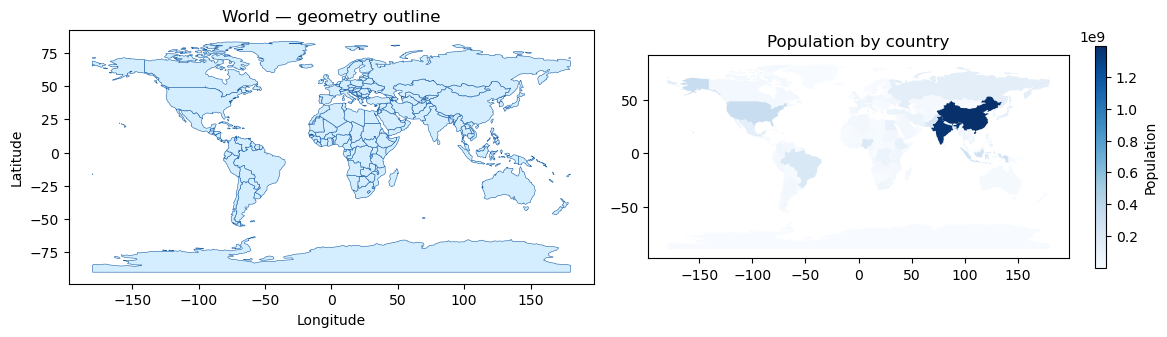


Data types:
pop_est        float64
continent       object
name            object
iso_a3          object
gdp_md_est       int64
geometry      geometry
dtype: object

Numeric summary:
            pop_est  gdp_md_est
count  1.770000e+02       177.0
mean   4.324346e+07    493474.0
std    1.513543e+08   2019326.0
min    1.400000e+02        16.0
25%    3.301000e+06     13469.0
50%    1.019232e+07     50400.0
75%    3.182530e+07    261921.0
max    1.397715e+09  21433226.0


In [2]:
# [Python] Quick plots to visually confirm the data makes sense

import geopandas as gpd
import matplotlib.pyplot as plt

states = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: outlines only
states.plot(ax=axes[0],
            facecolor="#d4edff",
            edgecolor="#185FA5",
            linewidth=0.4)
axes[0].set_title("World — geometry outline")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Plot 2: choropleth (population)
states.plot(ax=axes[1],
            column="pop_est",
            cmap="Blues",
            legend=True,
            legend_kwds={"label": "Population", "shrink": 0.6})
axes[1].set_title("Population by country")

plt.tight_layout()
plt.show()

# Attribute table summary
print("\nData types:")
print(states.dtypes)
print("\nNumeric summary:")
print(states[["pop_est", "gdp_md_est"]].describe().round(0))

### 1c — Loading from files (the real-world pattern)

In practice you'll load your own files. Here's the syntax you'll use repeatedly:

In [ ]:
# [R] Reading common spatial file formats

library(sf)

# Shapefile
# my_data <- st_read("path/to/watersheds.shp")

# GeoJSON
# my_data <- st_read("path/to/parcels.geojson")

# File geodatabase layer
# my_data <- st_read("path/to/project.gdb", layer = "streams")

# GeoPackage (preferred open format — single file, multiple layers)
# my_data <- st_read("path/to/project.gpkg", layer = "study_area")

# List layers in a file geodatabase or GeoPackage
# st_layers("path/to/project.gpkg")

# After loading — always run the sanity check
sanity_check_r <- function(layer, label = "layer") {
  cat("\n====", label, "====\n")
  cat("Features:", nrow(layer), "| Columns:", ncol(layer), "\n")
  cat("Geometry:", as.character(unique(st_geometry_type(layer))), "\n")
  cat("CRS EPSG:", st_crs(layer)$epsg, "\n")
  cat("Empty geoms:", sum(st_is_empty(layer)), "\n")
}

# Usage: sanity_check_r(my_data, "Watersheds")

# Demo with built-in data
library(spData)
sanity_check_r(us_states, "US States")

In [7]:
# [Python] Reading common spatial file formats

import geopandas as gpd

# Shapefile
# my_data = gpd.read_file("path/to/watersheds.shp")

# GeoJSON
# my_data = gpd.read_file("path/to/parcels.geojson")

# File geodatabase layer
# my_data = gpd.read_file("path/to/project.gdb", layer="streams")

# GeoPackage
# my_data = gpd.read_file("path/to/project.gpkg", layer="study_area")

# List layers in a GeoPackage
# import fiona; fiona.listlayers("project.gpkg")

# After loading — always run the sanity check
def sanity_check(gdf, label="layer"):
    """Print key properties of a GeoDataFrame."""
    print(f"\n==== {label} ====")
    print(f"Features: {len(gdf)} | Columns: {len(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
    print(f"CRS: {gdf.crs}")
    null_count = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"Null/empty geometries: {null_count}")
    print(f"Bounds: {gdf.total_bounds.round(4)}")

# Demo with built-in data
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
sanity_check(world, "World Countries")


==== World Countries ====
Features: 177 | Columns: 6
Geometry types: ['MultiPolygon' 'Polygon']
CRS: EPSG:4326
Null/empty geometries: 0
Bounds: [-180.      -90.      180.       83.6451]


<positron-console-cell-7>:32: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.


### 🔧 Try it yourself — Load and sanity check
- Run `sanity_check_r()` / `sanity_check()` on a dataset you care about (download any shapefile from your local government open data portal, or use the built-in `world` dataset in R/Python).
- What does the bounding box tell you? Does it match what you expect geographically?
- If the CRS is unexpected, look up what EPSG code your data *should* be in for your study area.

---
## Section 2 — Clone the ArcGIS Pro Base Python Environment

ArcGIS Pro ships with a **read-only** base Python environment. You can't safely install new packages there because an update could break things.

The solution: **clone it** into your own environment. Then you can install freely, and if anything breaks, you still have the original base.

```
ArcGIS Pro base env (read-only, don't touch)
    └── your-clone-env  ← install packages here
```

### Two ways to clone

| Method | Best for |
|---|---|
| ArcGIS Pro Package Manager (GUI) | Quick, no terminal needed |
| Command line (`conda`) | Automation, reproducibility, remote work |

> **Note:** This section uses `[Terminal]` cells — paste these into your terminal or Anaconda Prompt, not into a notebook code cell.

### Method 1 — GUI: ArcGIS Pro Package Manager

1. Open **ArcGIS Pro**
2. Go to **Project → Python** (in the left ribbon)
3. Click **Manage Environments**
4. In the **Active Environment** dropdown, click **Clone Default**
5. Name your environment — use something clear: `gispr` or `arcgispro-gispr`
6. Wait for the clone to complete (may take a few minutes)
7. Select your new environment as the **Active Environment**
8. Restart ArcGIS Pro

Your new environment is now active. Any packages you install from the Package Manager go here.

### Method 2 — Command line: `conda`

This gives you more control and is reproducible — you can share the command with teammates.

> Run the cells below in your **terminal / Anaconda Prompt**, not in this notebook.

In [ ]:
# [Terminal] Step 1: Find the path to the ArcGIS Pro base environment
# On Windows, the default is something like:
#   C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3

# This command shows all conda environments and their paths:
# conda env list

# Or: print the path from within ArcGIS Pro's Python window:
# import sys; print(sys.prefix)

In [ ]:
# [Terminal] Step 2: Clone the base environment
# Replace the path below with your actual ArcGIS Pro env path

# Windows:
# conda create --name gispr --clone "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3"

# Mac/Linux (if applicable):
# conda create --name gispr --clone /path/to/arcgispro-py3

# This takes a few minutes — it copies everything.
# When complete you'll see: "# To activate this environment, use:"
# conda activate gispr

In [ ]:
# [Terminal] Step 3: Activate your new environment and verify it

# conda activate gispr

# Confirm which Python is active:
# python --version
# conda info

# List installed packages (should look like a copy of arcgispro-py3):
# conda list | head -30

# Confirm arcpy is available (if you're on a licensed machine):
# python -c "import arcpy; print(arcpy.GetInstallInfo()['Version'])"

In [ ]:
# [Terminal] Step 4: Install additional packages into YOUR environment
# (never do this in the base arcgispro-py3 environment)

# Make sure gispr is active first:
# conda activate gispr

# Install packages:
# conda install -c conda-forge geopandas jupyterlab

# Or with pip (inside the active conda env):
# pip install geodatasets

# Register the env as a Jupyter kernel so you can select it in JupyterLab:
# python -m ipykernel install --user --name gispr --display-name "Python (gispr)"

In [ ]:
# [Python] Verify you're running in the right environment
# After switching your JupyterLab kernel to 'gispr', run this:

import sys
import os

print(f"Python version:   {sys.version}")
print(f"Environment path: {sys.prefix}")
print(f"Kernel name:      {os.path.basename(sys.prefix)}")

# Confirm key packages are present
import importlib
packages_to_check = ["geopandas", "arcpy", "pandas", "numpy", "shapely", "matplotlib"]

print("\nPackage availability:")
for pkg in packages_to_check:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "(no version attr)")
        print(f"  ✓ {pkg:<15} {version}")
    except ImportError:
        print(f"  ✗ {pkg:<15} NOT FOUND")

### 🔧 Try it yourself — Environment
- Clone the environment using **both** methods and verify you get the same result.
- Run the verification cell above in your cloned environment vs the base. Do the paths differ?
- Install one package you know you'll need (`folium` is a good one for interactive maps) and confirm it appears in `conda list`.

---
## Section 3 — Loops + If/Else: Make the Code Do the Boring Work

In GIS you rarely process one feature. You process hundreds or thousands — and you want consistent rules applied to all of them. Loops and conditionals are how you do that.

**Pattern we'll practice:**
1. Loop over rows in a spatial dataset
2. Apply an `if/else` rule to each row
3. Write the result to a new column
4. Verify the output makes sense

We'll use the same world countries dataset from Section 1.

### 3a — Loops and if/else in R

In [ ]:
# [R] Loops and if/else — categorize precipitation data

library(sf)
library(spData)

states <- us_states

# ── Example 1: For loop to flag records ──────────────────────
# We'll classify states by population size

# First: add an empty column to fill
states$pop_class <- NA_character_

for (i in seq_len(nrow(states))) {
  pop <- states$total_pop_15[i]
  
  if (is.na(pop)) {
    states$pop_class[i] <- "unknown"
  } else if (pop >= 10000000) {
    states$pop_class[i] <- "large"       # 10M+
  } else if (pop >= 2000000) {
    states$pop_class[i] <- "medium"      # 2M–10M
  } else {
    states$pop_class[i] <- "small"       # under 2M
  }
}

# Verify: check the distribution of categories
cat("Population class breakdown:\n")
print(table(states$pop_class))

# Double-check a specific case
cat("\nCalifornia:", states$pop_class[states$NAME == "California"], "\n")
cat("Wyoming:",    states$pop_class[states$NAME == "Wyoming"], "\n")

# Show the result table
cat("\nSample output:\n")
print(states[, c("NAME", "total_pop_15", "pop_class")][order(states$total_pop_15, decreasing = TRUE), ][1:8, ])

In [ ]:
# [R] Vectorized alternative — often preferred in R over explicit loops
# dplyr::case_when is the idiomatic R approach for this kind of classification

library(spData)
library(dplyr)
library(sf)

states <- us_states

# The vectorized equivalent — same logic, no explicit loop
states <- states %>%
  mutate(
    pop_class = case_when(
      is.na(total_pop_15)       ~ "unknown",
      total_pop_15 >= 10000000  ~ "large",
      total_pop_15 >=  2000000  ~ "medium",
      TRUE                      ~ "small"
    )
  )

# Verify
print(table(states$pop_class))

# Plot the result
plot(states["pop_class"],
     main   = "US States by Population Class",
     border = "white",
     lwd    = 0.3)

# When to use a loop vs vectorized:
# Loop: when each iteration depends on the PREVIOUS row, or you need complex
#       multi-step logic per feature.
# Vectorized (case_when, ifelse): when applying independent rules per row — faster.

### 3b — Loops and if/else in Python

In [ ]:
# [Python] Loops and if/else — classify countries by population

import geopandas as gpd
import pandas as pd

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── Example 1: Explicit for loop ────────────────────────────
# Classify countries by population (same logic, different dataset)

pop_classes = []  # build the list, then assign as a column

for i, row in world.iterrows():
    pop = row["pop_est"]
    
    if pd.isna(pop):
        pop_classes.append("unknown")
    elif pop >= 100_000_000:   # 100M+
        pop_classes.append("large")
    elif pop >= 10_000_000:    # 10M–100M
        pop_classes.append("medium")
    else:
        pop_classes.append("small")

world["pop_class"] = pop_classes

# Verify
print("Population class breakdown:")
print(world["pop_class"].value_counts())

# Spot-check
china = world[world["name"] == "China"]
print(f"\nChina pop_class: {china['pop_class'].values[0]}")

# Show top 5 by population
print("\nTop 5 most populous:")
print(world[["name", "pop_est", "pop_class"]]
      .sort_values("pop_est", ascending=False)
      .head())

In [ ]:
# [Python] Vectorized alternative — pandas apply and np.select
# This is faster than iterrows() for large datasets

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# np.select: define conditions and choices (evaluated in order)
conditions = [
    world["pop_est"].isna(),
    world["pop_est"] >= 100_000_000,
    world["pop_est"] >=  10_000_000,
]
choices = ["unknown", "large", "medium"]
world["pop_class"] = np.select(conditions, choices, default="small")

# Verify
print(world["pop_class"].value_counts())

# Plot the result as a categorical choropleth
fig, ax = plt.subplots(figsize=(12, 5))
world.plot(
    ax=ax,
    column="pop_class",
    categorical=True,
    legend=True,
    cmap="Set2",
    edgecolor="white",
    linewidth=0.3
)
ax.set_title("Countries by Population Class")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# When to use iterrows vs vectorized:
# iterrows: fine for small datasets; easier to debug; shows the loop structure clearly.
# np.select / .apply: much faster for 10K+ rows; preferred in production.

### 🔧 Try it yourself — Loops and conditionals
- Add a new column `area_class` that classifies features by their **geometry area** (use `st_area()` in R or `.area` in Python after projecting to an equal-area CRS).
- Write a loop that **prints a warning message** for any feature with a null/empty geometry.
- Try the same logic with both the explicit loop and the vectorized approach. Which is easier to read? Which would be faster on 50,000 features?

---
## Section 4 — Write One Tiny Reusable Function

This is the moment your code starts feeling like a **tool** rather than a one-off experiment.

The rule: if you find yourself writing the same block of code twice, wrap it in a function.

**We'll build three progressively useful functions:**
1. A field standardizer — cleans up inconsistent text values
2. A new-attribute calculator — computes a derived field
3. The `sanity_check()` function you already wrote in Section 1 — but now we'll call it on 3 different datasets to prove reusability

### 4a — Reusable functions in R

In [ ]:
# [R] Three reusable functions — written once, called many times

library(sf)
library(spData)

# ── Function 1: Standardize a text field ─────────────────────
# Converts to lowercase, trims whitespace, replaces spaces with underscores
# Use this whenever you're joining or comparing text fields from different sources

standardize_text <- function(x) {
  x <- tolower(trimws(x))          # lowercase + strip leading/trailing spaces
  x <- gsub("\\s+", "_", x)        # spaces → underscores
  x <- gsub("[^a-z0-9_]", "", x)  # remove any remaining special characters
  return(x)
}

# Prove it's reusable — call it on different inputs
standardize_text("New York")         # "new_york"
standardize_text("  Pacific Ocean ") # "pacific_ocean"
standardize_text("King County (WA)") # "king_county_wa"

# Apply to a whole column
states <- us_states
states$name_clean <- standardize_text(states$NAME)
head(states[, c("NAME", "name_clean")], 6)

# ── Function 2: Compute population density ───────────────────
# Takes a spatial layer and two column names; returns density in pop/km²

compute_density <- function(layer, pop_col, area_col = NULL) {
  if (is.null(area_col)) {
    # Compute area from geometry if no area column provided
    area_km2 <- as.numeric(st_area(layer)) / 1e6
  } else {
    area_km2 <- layer[[area_col]]
  }
  
  pop <- layer[[pop_col]]
  density <- round(pop / area_km2, 2)
  return(density)
}

# Call it — same function, different layers or columns
states$density_2010 <- compute_density(states, "total_pop_10")
states$density_2015 <- compute_density(states, "total_pop_15")

cat("\nPopulation density (pop/km²):\n")
print(states[order(-states$density_2015), c("NAME", "density_2010", "density_2015")][1:8, ])

# ── Function 3: Sanity check (from Section 1) ─────────────────
# Already written — let's call it on 3 different datasets

sanity_check_r <- function(layer, label = "layer") {
  cat("\n====", label, "====\n")
  cat("Features:", nrow(layer), "| Columns:", ncol(layer), "\n")
  cat("Geometry:", as.character(unique(st_geometry_type(layer))), "\n")
  cat("CRS EPSG:", st_crs(layer)$epsg, "\n")
  cat("Empty geoms:", sum(st_is_empty(layer)), "\n")
}

sanity_check_r(us_states, "US States")
sanity_check_r(world,     "World Countries")   # from spData
sanity_check_r(us_states[us_states$REGION == "West", ], "Western US States")

### 4b — Reusable functions in Python

In [ ]:
# [Python] Three reusable functions — written once, called many times

import geopandas as gpd
import pandas as pd
import re

# ── Function 1: Standardize a text field ─────────────────────

def standardize_text(text):
    """Convert to lowercase, strip whitespace, replace spaces with underscores,
    and remove special characters. Returns a clean, join-safe string."""
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"\s+", "_", text)          # spaces → underscores
    text = re.sub(r"[^a-z0-9_]", "", text)    # remove special chars
    return text

# Prove it's reusable — call on different inputs
print(standardize_text("New York"))          # new_york
print(standardize_text("  Pacific Ocean "))  # pacific_ocean
print(standardize_text("King County (WA)"))  # king_county_wa

# Apply to a whole column with .apply()
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
world["name_clean"] = world["name"].apply(standardize_text)
print("\nName standardization sample:")
print(world[["name", "name_clean"]].head(6))

# ── Function 2: Compute population density ───────────────────

def compute_density(gdf, pop_col, area_col=None):
    """Compute population density (pop per km²).
    Projects to equal-area CRS if no area column is provided."""
    if area_col is None:
        # Project to equal-area for accurate area calculation
        projected = gdf.to_crs("EPSG:6933")       # World Cylindrical Equal Area
        area_km2 = projected.geometry.area / 1e6
    else:
        area_km2 = gdf[area_col]
    
    density = (gdf[pop_col] / area_km2).round(2)
    return density

# Call it — same function, different datasets or columns
world["pop_density"] = compute_density(world, "pop_est")

print("\nTop 10 most densely populated countries:")
print(world[["name", "pop_est", "pop_density"]]
      .sort_values("pop_density", ascending=False)
      .head(10)[["name", "pop_density"]])

# ── Function 3: sanity_check (from Section 1) ─────────────────

def sanity_check(gdf, label="layer"):
    """Print key properties of a GeoDataFrame."""
    print(f"\n==== {label} ====")
    print(f"Features: {len(gdf)} | Columns: {len(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
    print(f"CRS: {gdf.crs}")
    null_count = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"Null/empty geometries: {null_count}")

# Call on 3 different datasets — same function, no copy-paste
sanity_check(world, "World Countries")
north_america = world[world["continent"] == "North America"]
sanity_check(north_america, "North America only")
large = world[world["pop_density"] > 200]
sanity_check(large, "Dense countries (>200 pop/km²)")

### 🔧 Try it yourself — Functions
- Write a function `flag_boundary_issues(gdf, threshold_km)` that returns a filtered GeoDataFrame of features whose perimeter-to-area ratio exceeds a threshold (a rough indicator of jagged or slivered polygons).
- Call it on two different subsets of the world dataset.
- Add a `verbose=True` parameter that prints a summary when True and stays silent when False.

---
## Section 5 — Version Control: Git + GitHub

This is the habit that makes everything else sustainable.

**Why bother for GIS work?**
- Track what changed between your analysis runs
- Collaborate with teammates without emailing files
- Roll back to a working version when something breaks
- Build a portfolio of reproducible spatial analyses

### The workflow we're building

```
Your local machine            GitHub (remote)
─────────────────             ───────────────
[working files]
      │  git add
      ▼
[staging area]
      │  git commit
      ▼
[local repo]  ──── git push ──► [remote repo]
```

> **Before starting:** Install Git from [git-scm.com](https://git-scm.com) and create a free account at [github.com](https://github.com) if you haven't already.

All cells in this section are `[Terminal]` — run them in your terminal, not in JupyterLab.

### 5a — First-time Git setup (do this once per machine)

In [ ]:
# [Terminal] One-time Git configuration
# Replace with your actual name and GitHub email

# git config --global user.name  "Your Name"
# git config --global user.email "you@example.com"

# Verify the config:
# git config --list

# Set VS Code (or your preferred editor) for commit messages:
# git config --global core.editor "code --wait"   # VS Code
# git config --global core.editor "nano"           # nano (simpler)

# Check Git version:
# git --version

### 5b — Initialize a repo for this week's work

In [ ]:
# [Terminal] Create a project folder and initialize Git

# Create and navigate to your project folder:
# mkdir gispr-module2
# cd gispr-module2

# Initialize a Git repository:
# git init
# You'll see: Initialized empty Git repository in .../gispr-module2/.git/

# Check the current status (should show empty):
# git status

In [ ]:
# [Terminal] Create a .gitignore file to keep junk out of your repo
# A .gitignore tells Git which files to never track

# The lines below create a .gitignore from the terminal:
# (On Windows, use a text editor instead)

# cat > .gitignore << 'EOF'
# # Python
# __pycache__/
# *.py[cod]
# .ipynb_checkpoints/
# *.egg-info/

# # R
# .Rhistory
# .RData
# .Rproj.user/

# # Data files (often too large for GitHub)
# *.shp
# *.dbf
# *.shx
# *.prj
# *.tif
# data/raw/

# # OS files
# .DS_Store
# Thumbs.db
# EOF

# Verify it was created:
# cat .gitignore

### 5c — Your first commits (the add → commit loop)

In [ ]:
# [Terminal] Stage and commit files — the core Git loop

# Copy this notebook into your project folder first, then:

# Step 1: See what's changed / untracked
# git status

# Step 2: Stage files for the next commit
# git add .gitignore                           # a specific file
# git add GISPR_Module2_SpatialFoundations.ipynb
# git add .                                    # everything untracked

# Step 3: Commit with a descriptive message
# git commit -m "Initial commit: add module 2 notebook and gitignore"

# After more work, commit again:
# git add .
# git commit -m "Section 1: add sanity_check function and load world dataset"

# View the commit log:
# git log --oneline

# View what changed in the last commit:
# git show HEAD

### 5d — Push to GitHub

In [ ]:
# [Terminal] Connect your local repo to GitHub and push

# First: create a NEW empty repository on github.com
#   → Click "New" on your GitHub profile
#   → Name it: gispr-module2
#   → DO NOT initialize with README (we already have local files)
#   → Click "Create repository"
#   → GitHub will show you commands — use the ones below

# Add GitHub as the remote (replace YOUR_USERNAME):
# git remote add origin https://github.com/YOUR_USERNAME/gispr-module2.git

# Rename the default branch to 'main' (GitHub's current default):
# git branch -M main

# Push your local commits to GitHub:
# git push -u origin main

# The -u flag sets 'origin main' as the default, so future pushes are just:
# git push

# Verify: visit https://github.com/YOUR_USERNAME/gispr-module2

### 5e — The ongoing workflow

Once set up, your daily Git workflow is just four commands repeated:

```bash
# 1. See what changed
git status

# 2. Stage your changes
git add .

# 3. Commit with a clear message
git commit -m "what you did and why, in plain English"

# 4. Push to GitHub
git push
```

### Writing good commit messages

| ❌ Avoid | ✓ Prefer |
|---|---|
| `"updated stuff"` | `"Add pop_class column using case_when classification"` |
| `"fixed it"` | `"Fix CRS mismatch: reproject streams to EPSG:32610 before join"` |
| `"wip"` | `"WIP: compute_density function working, tests needed"` |
| `"changes"` | `"Refactor sanity_check to accept any GeoDataFrame, not just states"` |

**Rule of thumb:** Future You should be able to read the commit log and understand what happened without opening the files.

In [ ]:
# [Terminal] Helpful Git commands for day-to-day use

# See a compact history of all commits:
# git log --oneline

# See exactly what changed in a specific file since last commit:
# git diff GISPR_Module2_SpatialFoundations.ipynb

# Undo changes to a file (revert to last committed version):
# git checkout -- filename.py

# Create a branch for experimental work (keeps main safe):
# git checkout -b my-experiment

# Pull latest changes from GitHub (if collaborating):
# git pull

# See all remote connections:
# git remote -v

### 🔧 Try it yourself — Git + GitHub
1. Initialize a repo for your Module 2 work.
2. Make at least **3 meaningful commits** as you work through this notebook — one per section you complete.
3. Push to GitHub and confirm the files are visible on the web.
4. Run `git log --oneline` and read your commit history. Does Future You understand what happened?

---
## Putting it all together — Mini end-to-end workflow

Let's chain everything from this module into one coherent script. This is the pattern you'll repeat throughout the course:

> **Load → Sanity check → Process (loops + functions) → Output → Commit**

In [ ]:
# [Python] Full end-to-end: load, check, classify, compute, save, document

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Step 1: Load ──────────────────────────────────────────────
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── Step 2: Sanity check ──────────────────────────────────────
def sanity_check(gdf, label="layer"):
    """Print key properties of a GeoDataFrame."""
    print(f"\n==== {label} ====")
    print(f"Features: {len(gdf)} | Columns: {len(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
    print(f"CRS: {gdf.crs}")
    null_count = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"Null/empty geometries: {null_count}")

sanity_check(world, "World Countries (raw)")

# ── Step 3: Process — functions + loops ───────────────────────
def standardize_text(text):
    """Clean text field for safe joins and comparisons."""
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^a-z0-9_]", "", text)
    return text

def compute_density(gdf, pop_col):
    """Population density in pop/km², using equal-area projection."""
    projected = gdf.to_crs("EPSG:6933")
    area_km2 = projected.geometry.area / 1e6
    return (gdf[pop_col] / area_km2).round(2)

# Apply functions
world["name_clean"]   = world["name"].apply(standardize_text)
world["pop_density"]  = compute_density(world, "pop_est")

# Loop to classify
conditions = [
    world["pop_est"].isna(),
    world["pop_est"] >= 100_000_000,
    world["pop_est"] >=  10_000_000,
]
world["pop_class"] = np.select(conditions, ["unknown", "large", "medium"], default="small")

# ── Step 4: Verify the results ────────────────────────────────
sanity_check(world, "World Countries (processed)")
print("\nClass breakdown:")
print(world["pop_class"].value_counts())
print("\nTop 5 by density:")
print(world[["name", "pop_class", "pop_density"]]
      .sort_values("pop_density", ascending=False)
      .head(5))

# ── Step 5: Visualize ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
world.plot(ax=ax, column="pop_density",
           cmap="YlOrRd", legend=True,
           legend_kwds={"label": "Pop/km²", "shrink": 0.5},
           edgecolor="white", linewidth=0.3,
           missing_kwds={"color": "lightgray"})
ax.set_title("Population Density by Country (pop/km²)")
plt.tight_layout()
plt.savefig("output_density_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nMap saved: output_density_map.png")

# ── Step 6: Save processed data ───────────────────────────────
world.to_file("world_processed.gpkg", driver="GPKG")
print("Data saved: world_processed.gpkg")
print("\nNext step: git add . && git commit -m 'Add density classification and output map'")

---
## ✅ Module 2 Homework — Deliverables

Submit **two screenshots** and a **GitHub repo link**:

### Screenshot 1 — Spatial data loaded and sanity-checked
Show:
- Your data successfully loaded (R or Python — your choice)
- The output of your sanity check showing geometry type and CRS
- A plot of the loaded layer

### Screenshot 2 — Loop + function output
Show:
- A new column added to your dataset via a loop or classification rule
- The function called **at least twice** on different inputs
- A print or table output that confirms the result is correct

### GitHub repo link
Your repo should have:
- At least **3 commits** with clear messages
- This notebook (or your version of it) in the repo
- A `.gitignore` file

---

**Stuck?** Post in Ed Discussion with your error message, the cell that failed, and your OS/environment. If you solved an error, share how — someone else is probably hitting the same thing.